# Bonus B3 — Monte Carlo NAV Simulation

## Objective

This analysis uses Monte Carlo simulation to project possible future NAV paths for selected mutual funds over a 5-year horizon.

Historical NAV data is used to estimate daily returns, average return, and volatility. Thousands of simulated return paths are then generated to estimate a range of possible future NAV outcomes.

### Selected Funds
- SBI Bluechip
- ICICI Bluechip
- Nippon Large Cap
- Axis Bluechip
- Kotak Bluechip

### Simulation Parameters
- Forecast horizon: 5 years
- Trading days per year: 252
- Total forecast days: 1,260
- Number of simulations: 5,000

### Important Note

Monte Carlo results represent probabilistic scenarios based on historical return and volatility characteristics. They are not guaranteed predictions of future NAV performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

NAV_FILE = PROJECT_ROOT / "data" / "processed" / "02_nav_history_cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = PROJECT_ROOT / "reports" / "charts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("NAV file:", NAV_FILE)
print("Output directory:", OUTPUT_DIR)

NAV file: c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\data\processed\02_nav_history_cleaned.csv
Output directory: c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs


In [3]:
nav = pd.read_csv(NAV_FILE)

nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

nav = nav.dropna(subset=["date", "nav"])
nav = nav[nav["nav"] > 0]

nav = nav.sort_values(["amfi_code", "date"])

print("Rows:", len(nav))
print("Funds:", nav["amfi_code"].nunique())
print(nav.head())

Rows: 46000
Funds: 40
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [4]:
selected_funds = {
    "SBI Bluechip": 119551,
    "ICICI Bluechip": 120503,
    "Nippon Large Cap": 118632,
    "Axis Bluechip": 119092,
    "Kotak Bluechip": 120841
}

selected_nav = nav[
    nav["amfi_code"].isin(selected_funds.values())
].copy()

print("Selected funds:", selected_nav["amfi_code"].nunique())
print("Rows:", len(selected_nav))

Selected funds: 5
Rows: 5750


In [5]:
selected_nav = selected_nav.sort_values(
    ["amfi_code", "date"]
)

selected_nav["daily_return"] = (
    selected_nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

selected_nav = selected_nav.dropna(
    subset=["daily_return"]
)

print(selected_nav.head())

       amfi_code       date      nav  daily_return
10351     118632 2022-01-04  42.8033     -0.000714
10352     118632 2022-01-05  43.0564      0.005913
10353     118632 2022-01-06  43.2088      0.003540
10354     118632 2022-01-07  42.9585     -0.005793
10355     118632 2022-01-10  43.2317      0.006360


In [6]:
statistics = (
    selected_nav
    .groupby("amfi_code")["daily_return"]
    .agg(
        mean_daily_return="mean",
        daily_volatility="std"
    )
    .reset_index()
)

statistics["annualized_return"] = (
    statistics["mean_daily_return"] * 252
)

statistics["annualized_volatility"] = (
    statistics["daily_volatility"] * np.sqrt(252)
)

statistics

,amfi_code,mean_daily_return,daily_volatility,annualized_return,annualized_volatility
0,118632,0.000865,0.008913,0.218037,0.141484
1,119092,0.000275,0.008788,0.069295,0.139507
2,119551,0.000917,0.008656,0.231033,0.137414
3,120503,0.000698,0.008746,0.175794,0.138844
4,120841,0.000522,0.008481,0.131548,0.134638


In [7]:
code_to_name = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

statistics["scheme_name"] = (
    statistics["amfi_code"]
    .map(code_to_name)
)

statistics = statistics[
    [
        "amfi_code",
        "scheme_name",
        "mean_daily_return",
        "daily_volatility",
        "annualized_return",
        "annualized_volatility"
    ]
]

statistics

,amfi_code,scheme_name,mean_daily_return,daily_volatility,annualized_return,annualized_volatility
0,118632,Nippon Large Cap,0.000865,0.008913,0.218037,0.141484
1,119092,Axis Bluechip,0.000275,0.008788,0.069295,0.139507
2,119551,SBI Bluechip,0.000917,0.008656,0.231033,0.137414
3,120503,ICICI Bluechip,0.000698,0.008746,0.175794,0.138844
4,120841,Kotak Bluechip,0.000522,0.008481,0.131548,0.134638


In [8]:
TRADING_DAYS = 252
YEARS = 5
FORECAST_DAYS = TRADING_DAYS * YEARS
SIMULATIONS = 5000

print("Forecast days:", FORECAST_DAYS)
print("Simulations:", SIMULATIONS)

Forecast days: 1260
Simulations: 5000


In [9]:
latest_nav = (
    selected_nav
    .sort_values("date")
    .groupby("amfi_code")
    .tail(1)
    [
        ["amfi_code", "nav", "date"]
    ]
    .rename(columns={"nav": "starting_nav"})
)

latest_nav["scheme_name"] = (
    latest_nav["amfi_code"].map(code_to_name)
)

latest_nav

,amfi_code,starting_nav,date,scheme_name
22999,119551,149.3216,2026-05-29,SBI Bluechip
17249,119092,50.8387,2026-05-29,Axis Bluechip
11499,118632,110.5554,2026-05-29,Nippon Large Cap
27599,120503,118.1496,2026-05-29,ICICI Bluechip
33349,120841,482.1270,2026-05-29,Kotak Bluechip


In [13]:
def monte_carlo_simulation(
    starting_nav,
    mean_daily_return,
    daily_volatility,
    forecast_days=1260,
    simulations=5000
):
    random_returns = np.random.normal(
        loc=mean_daily_return,
        scale=daily_volatility,
        size=(forecast_days, simulations)
    )

    price_paths = starting_nav * np.cumprod(
        1 + random_returns,
        axis=0
    )

    return price_paths

In [14]:
simulation_results = {}

for _, row in statistics.iterrows():

    code = row["amfi_code"]
    name = row["scheme_name"]

    starting_value = latest_nav.loc[
        latest_nav["amfi_code"] == code,
        "starting_nav"
    ].iloc[0]

    paths = monte_carlo_simulation(
        starting_nav=starting_value,
        mean_daily_return=row["mean_daily_return"],
        daily_volatility=row["daily_volatility"],
        forecast_days=FORECAST_DAYS,
        simulations=SIMULATIONS
    )

    simulation_results[name] = paths

    print(
        f"{name}: "
        f"{paths.shape[0]} days × "
        f"{paths.shape[1]} simulations"
    )

Nippon Large Cap: 1260 days × 5000 simulations
Axis Bluechip: 1260 days × 5000 simulations
SBI Bluechip: 1260 days × 5000 simulations
ICICI Bluechip: 1260 days × 5000 simulations
Kotak Bluechip: 1260 days × 5000 simulations


In [15]:
summary = []

for name, paths in simulation_results.items():

    final_nav = paths[-1, :]

    starting_value = latest_nav.loc[
        latest_nav["scheme_name"] == name,
        "starting_nav"
    ].iloc[0]

    summary.append({
        "scheme_name": name,
        "starting_nav": starting_value,
        "5th_percentile": np.percentile(final_nav, 5),
        "25th_percentile": np.percentile(final_nav, 25),
        "median": np.percentile(final_nav, 50),
        "75th_percentile": np.percentile(final_nav, 75),
        "95th_percentile": np.percentile(final_nav, 95)
    })

monte_carlo_summary = pd.DataFrame(summary)

monte_carlo_summary

,scheme_name,starting_nav,5th_percentile,25th_percentile,median,75th_percentile,95th_percentile
0,Nippon Large Cap,110.5554,185.165841,250.635237,312.729194,387.290656,524.490660
1,Axis Bluechip,50.8387,40.876551,55.500873,68.539651,85.262628,114.178192
2,SBI Bluechip,149.3216,273.541731,366.474214,451.345950,552.552007,754.908901
3,ICICI Bluechip,118.1496,166.934171,220.546970,273.492642,338.258667,460.575394
4,Kotak Bluechip,482.1270,554.635896,727.805258,885.999117,1092.188747,1451.741494


In [16]:
output_file = OUTPUT_DIR / "monte_carlo_simulation.csv"

monte_carlo_summary.to_csv(
    output_file,
    index=False
)

print("Monte Carlo results saved successfully!")
print(output_file)

Monte Carlo results saved successfully!
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs\monte_carlo_simulation.csv


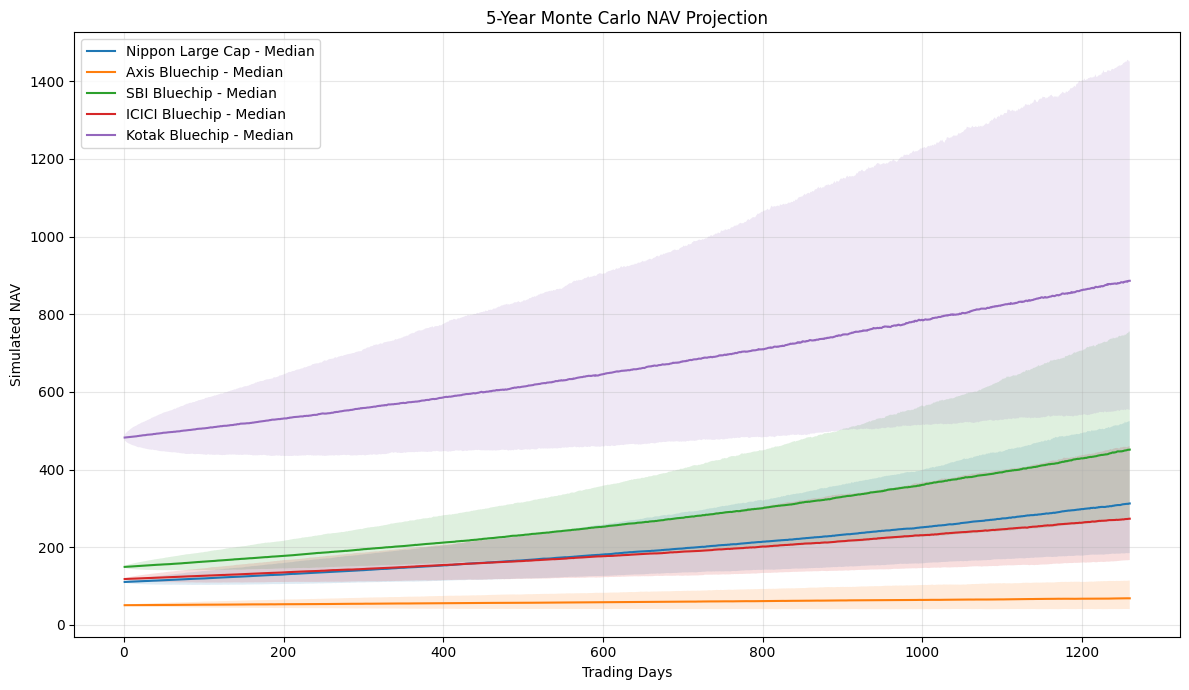

Chart saved successfully!
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\monte_carlo_projection.png


In [17]:
plt.figure(figsize=(12, 7))

for name, paths in simulation_results.items():

    # Calculate percentile bands for every simulated day
    p5 = np.percentile(paths, 5, axis=1)
    median = np.percentile(paths, 50, axis=1)
    p95 = np.percentile(paths, 95, axis=1)

    days = np.arange(1, FORECAST_DAYS + 1)

    plt.plot(
        days,
        median,
        label=f"{name} - Median"
    )

    plt.fill_between(
        days,
        p5,
        p95,
        alpha=0.15
    )

plt.title("5-Year Monte Carlo NAV Projection")
plt.xlabel("Trading Days")
plt.ylabel("Simulated NAV")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

chart_file = CHART_DIR / "monte_carlo_projection.png"

plt.savefig(
    chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")
print(chart_file)

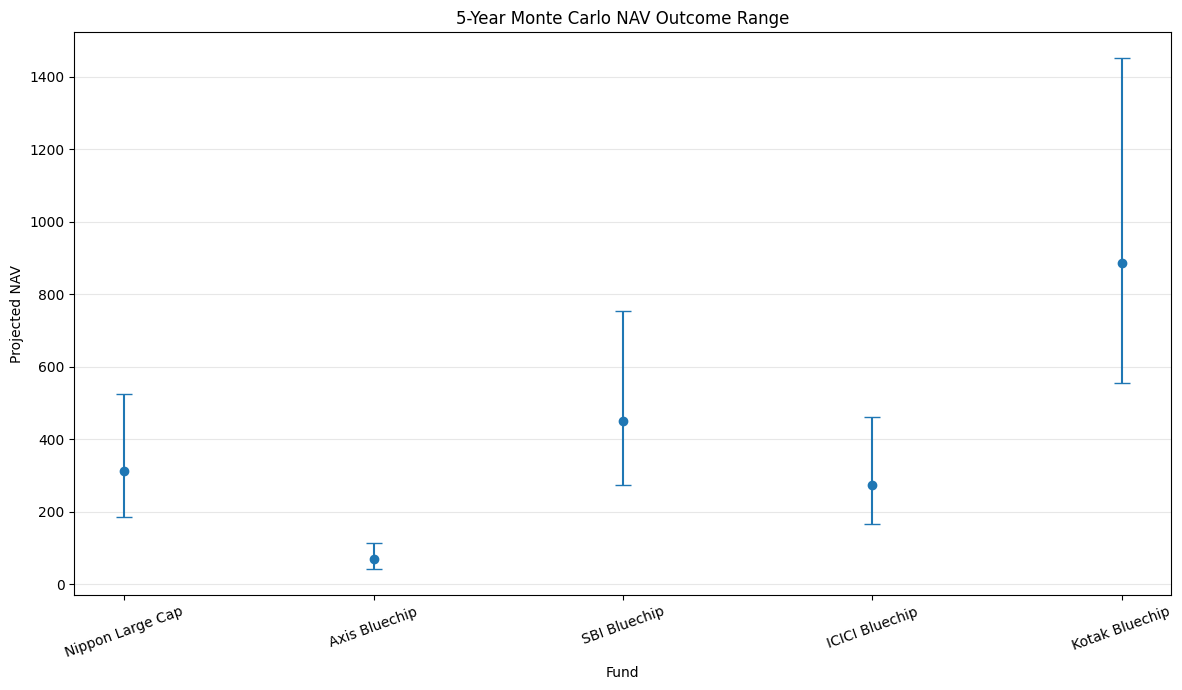

Comparison chart saved successfully!
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\monte_carlo_outcome_range.png


In [18]:
plt.figure(figsize=(12, 7))

x = np.arange(len(monte_carlo_summary))

median = monte_carlo_summary["median"].values
lower = median - monte_carlo_summary["5th_percentile"].values
upper = monte_carlo_summary["95th_percentile"].values - median

plt.errorbar(
    x,
    median,
    yerr=[lower, upper],
    fmt="o",
    capsize=6
)

plt.xticks(
    x,
    monte_carlo_summary["scheme_name"],
    rotation=20
)

plt.title("5-Year Monte Carlo NAV Outcome Range")
plt.xlabel("Fund")
plt.ylabel("Projected NAV")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

comparison_file = CHART_DIR / "monte_carlo_outcome_range.png"

plt.savefig(
    comparison_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison chart saved successfully!")
print(comparison_file)

## Monte Carlo Simulation Findings

The Monte Carlo simulation generated 5,000 possible NAV paths over a five-year period using historical daily return and volatility characteristics.

The results provide a probabilistic range rather than a guaranteed forecast.

### Key observations

- SBI Bluechip and Nippon Large Cap show relatively strong simulated median NAV growth.
- Kotak Bluechip has the highest projected median NAV among the selected funds, although its starting NAV is also substantially higher.
- Axis Bluechip has a comparatively lower projected median outcome and its 5th percentile falls below the current starting NAV.
- The wide 5th-to-95th percentile ranges demonstrate the uncertainty associated with long-term NAV projections.
- The simulation assumes that historical return and volatility characteristics remain broadly representative of future conditions.

### Important limitation

Monte Carlo simulation is a scenario-generation technique, not a prediction of actual future NAV. Real-world returns can be affected by market conditions, economic events, interest rates, fund management decisions, and other factors that are not captured by the model.

In [19]:
print("B3 Monte Carlo Simulation completed!")
print()
print("Output files:")
print(output_file)
print(chart_file)
print(comparison_file)

B3 Monte Carlo Simulation completed!

Output files:
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs\monte_carlo_simulation.csv
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\monte_carlo_projection.png
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\monte_carlo_outcome_range.png
